In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [51]:
df = pd.read_csv('User_Data.csv')

In [52]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [53]:
df = df.drop('User ID', axis = 1)

In [54]:
df.shape

(400, 4)

In [55]:
df.info

<bound method DataFrame.info of      Gender  Age  EstimatedSalary  Purchased
0      Male   19            19000          0
1      Male   35            20000          0
2    Female   26            43000          0
3    Female   27            57000          0
4      Male   19            76000          0
..      ...  ...              ...        ...
395  Female   46            41000          1
396    Male   51            23000          1
397  Female   50            20000          1
398    Male   36            33000          0
399  Female   49            36000          1

[400 rows x 4 columns]>

In [56]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [57]:
df.nunique()


Gender               2
Age                 43
EstimatedSalary    117
Purchased            2
dtype: int64

In [58]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [59]:
df['Gender'].count()

np.int64(400)

In [60]:
df['Age'].unique()

array([19, 35, 26, 27, 32, 25, 20, 18, 29, 47, 45, 46, 48, 49, 31, 21, 28,
       33, 30, 23, 24, 22, 59, 34, 39, 38, 37, 42, 40, 36, 41, 58, 55, 52,
       60, 56, 53, 50, 51, 57, 44, 43, 54])

In [61]:
df['Purchased'].unique()

array([0, 1])

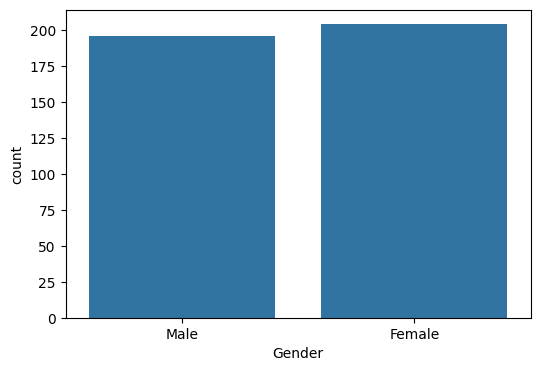

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.show()


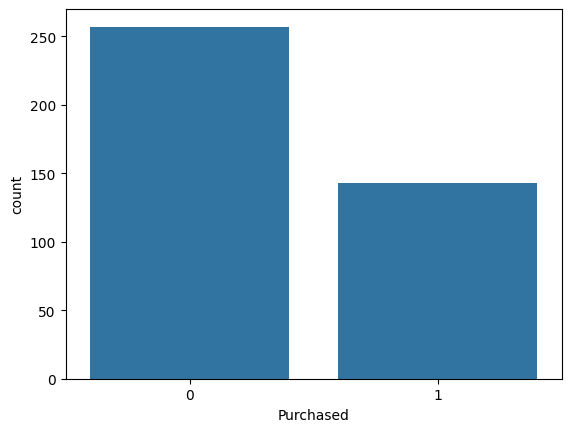

In [63]:
sns.countplot(x='Purchased', data=df)
plt.show()

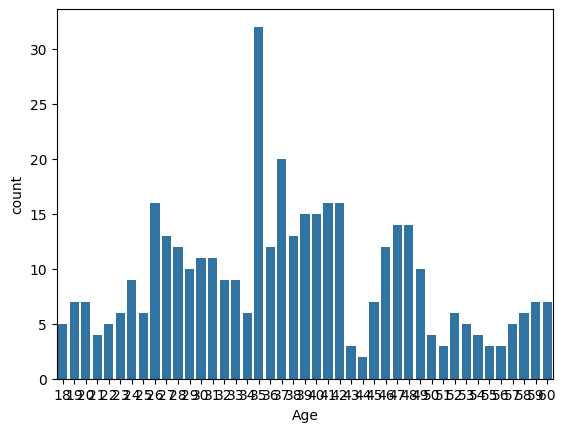

In [64]:
sns.countplot(x='Age', data=df)
plt.show()

In [65]:
# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [66]:
# Cost function
def calc_cost(Y, y_pred):
    m = Y.shape[0]
    cost = - (1/m) * np.sum(Y * np.log(y_pred + 1e-4) + (1 - Y) * np.log(1 - y_pred + 1e-4))
    return cost

**Loss function:**

$$J = -\frac{1}{m}\sum_{i=1}^{m} [y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$$


In [67]:
# Encode categorical variables (Gender: Male=1, Female=0)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Prepare features (X) and target (Y)
X = df.drop('Purchased', axis=1)
Y = df['Purchased']

In [68]:
w = np.zeros((X.shape[1], 1))

In [69]:
#weights
w 

array([[0.],
       [0.],
       [0.]])

In [70]:
#bias
b = 0

In [71]:
# Gradient Descent
def gradient_descent(X, Y, w, b, learning_rate, epochs):
    m = X.shape[0]
    costs = []

    for i in range(epochs):
        # Linear function
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        # Compute cost
        cost = calc_cost(Y, y_pred)

        # Gradients
        dw = (1/m) * np.dot(X.T, (y_pred - Y))
        db = (1/m) * np.sum(y_pred - Y)

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            costs.append(cost)
            print(f"Epoch {i}, Cost: {cost}")

    return w, b, costs

**Gradient Formulas:**

**Gradient with respect to weights:**
$$dw = \frac{1}{m} X^T (\hat{y} - y)$$

**Gradient with respect to bias:**
$$db = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$


In [72]:
w, b, costs = gradient_descent(X.values, Y.values.reshape(-1, 1), w, b, learning_rate=0.1, epochs=1000)

print("Final weights:\n", w)
print("Final bias:", b)

Epoch 0, Cost: 0.6929472005572793
Epoch 100, Cost: 3.2926324361937716
Epoch 200, Cost: 3.2926324361937716
Epoch 300, Cost: 5.917607940782079
Epoch 400, Cost: 5.917607940782079
Epoch 500, Cost: 3.2926324361937716
Epoch 600, Cost: 3.2926324361937716
Epoch 700, Cost: 5.917607940782079
Epoch 800, Cost: 5.917607940782079
Epoch 900, Cost: 3.2926324361937716
Final weights:
 [[   -5.1825 ]
 [   -7.73375]
 [-1855.625  ]]
Final bias: -8.499999999999982


/tmp/ipykernel_101071/2172004017.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [ ]:
# Prediction function
def predict(X, w, b):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    
    # Convert probabilities to binary (0 or 1) using if-else
    y_pred = (y_pred >= 0.5).astype(int)
    # OR
    # for i in range(len(y_pred)):
    #     if y_pred[i] >= 0.5:
    #         y_pred[i] = 1
    #     else:
    #         y_pred[i] = 0
    
    return y_pred     

In [74]:

# Make predictions on the training data
y_pred_train = predict(X.values, w, b)

# Display the predictions
print("Predictions on training data:\n", y_pred_train.tolist())

Predictions on training data:
 [[0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]

/tmp/ipykernel_101071/2172004017.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [77]:

def calculate_accuracy(y_true, y_pred):
    correct_predictions = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct_predictions += 1
    accuracy = correct_predictions / len(y_true)
    return accuracy

Y_reshaped = Y.values.reshape(-1, 1)

accuracy_train = calculate_accuracy(Y_reshaped, y_pred_train)
print(f"Accuracy on training data: {accuracy_train:.4f}")

test_loss = calc_cost(Y_reshaped, y_pred_train)
print(f"Test Loss: {test_loss:.4f}")

Accuracy on training data: 0.6425
Test Loss: 3.2926
